# 🛍️ Diwali Sales Analysis
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** 11,251 rows × 15 columns — Indian e-commerce Diwali sales data  
**Goal:** Identify the highest-value customer segments and product categories to guide future marketing decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline

# Style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')
print(f'Shape: {df.shape}')
df.head()

Shape: (11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [4]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


## 2. Data Cleaning

In [5]:
# Drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

# Check null values before dropping
print('Null values per column:')
print(pd.isnull(df).sum())

Null values per column:
User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64


In [6]:
# Drop rows with null values (12 rows in Amount column)
df.dropna(inplace=True)

# Fix data type: Amount should be integer
df['Amount'] = df['Amount'].astype('int')

print(f'Clean dataset shape: {df.shape}')
print(f'Amount dtype: {df["Amount"].dtype}')

Clean dataset shape: (11239, 13)
Amount dtype: int64


In [7]:
# Statistical summary of key numeric columns
df[['Age', 'Orders', 'Amount']].describe().round(2)

,Age,Orders,Amount
count,11239.00,11239.00,11239.00
mean,35.41,2.49,9453.61
std,12.75,1.11,5222.36
min,12.00,1.00,188.00
25%,27.00,2.00,5443.00
50%,33.00,2.00,8109.00
75%,43.00,3.00,12675.00
max,92.00,4.00,23952.00


> **Observations:**
> - Average order value: **₹9,454**  
> - Orders per customer range from 1–4, median is 2  
> - Age ranges from 12 to 92, median customer age is 33

## 3. Exploratory Data Analysis (EDA)

In [8]:
total_revenue = df['Amount'].sum()
total_orders = df['Orders'].sum()
total_customers = df['User_ID'].nunique()

print(f'Total Revenue:   ₹{total_revenue:,.0f}')
print(f'Total Orders:    {total_orders:,}')
print(f'Unique Customers:{total_customers:,}')
print(f'Avg Order Value: ₹{total_revenue/total_customers:,.0f}')

Total Revenue:   ₹106,249,129
Total Orders:    27,981
Unique Customers:3,752
Avg Order Value: ₹28,318


### 3.1 Gender Analysis

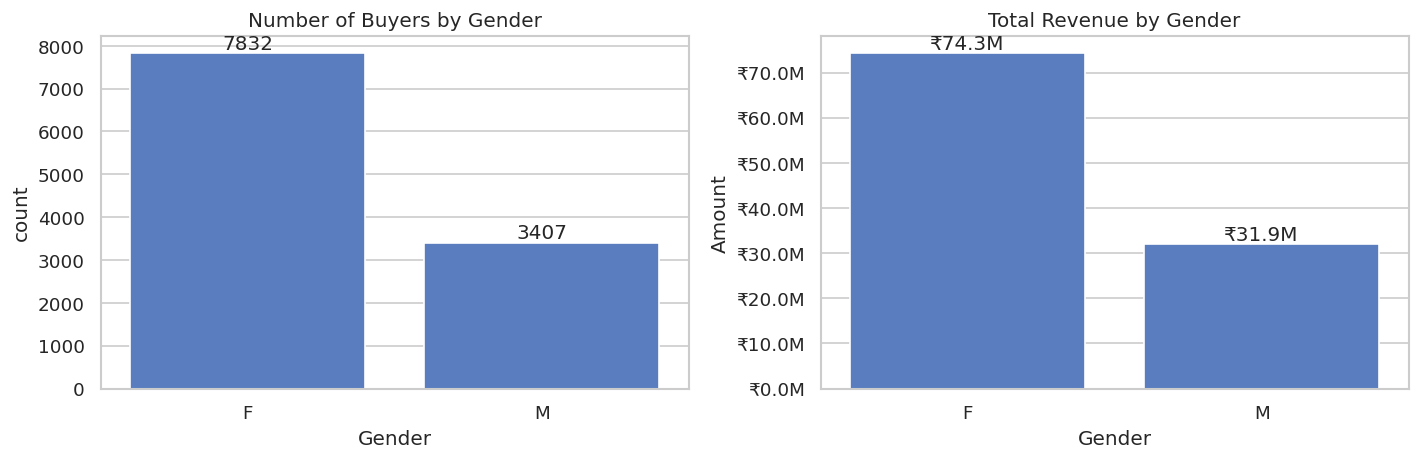

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
gender_count = df['Gender'].value_counts()
ax1 = sns.countplot(x='Gender', data=df, order=['F','M'], ax=axes[0])
axes[0].set_title('Number of Buyers by Gender')
axes[0].set_xlabel('Gender')
for bars in ax1.containers:
    ax1.bar_label(bars)

# Revenue
sales_gen = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
ax2 = sns.barplot(x='Gender', y='Amount', data=sales_gen, ax=axes[1])
axes[1].set_title('Total Revenue by Gender')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for bars in ax2.containers:
    ax2.bar_label(bars, fmt=lambda x: f'₹{x/1e6:.1f}M')

plt.tight_layout()
plt.show()

In [10]:
# % contribution by gender
gen_rev = df.groupby('Gender')['Amount'].sum()
print('Revenue contribution by gender:')
for g, amt in gen_rev.items():
    label = 'Female' if g == 'F' else 'Male'
    print(f'  {label}: ₹{amt:,.0f}  ({amt/total_revenue*100:.1f}% of total revenue)')

Revenue contribution by gender:
  Female: ₹74,335,853  (70.0% of total revenue)
  Male: ₹31,913,276  (30.0% of total revenue)


> **Insight:** Female buyers dominate both volume and revenue — **70% of total revenue (₹7.4 Crore)** comes from female customers, despite being a slightly higher count than males. This signals that female customers are both more numerous and higher-spending.

### 3.2 Age Group Analysis

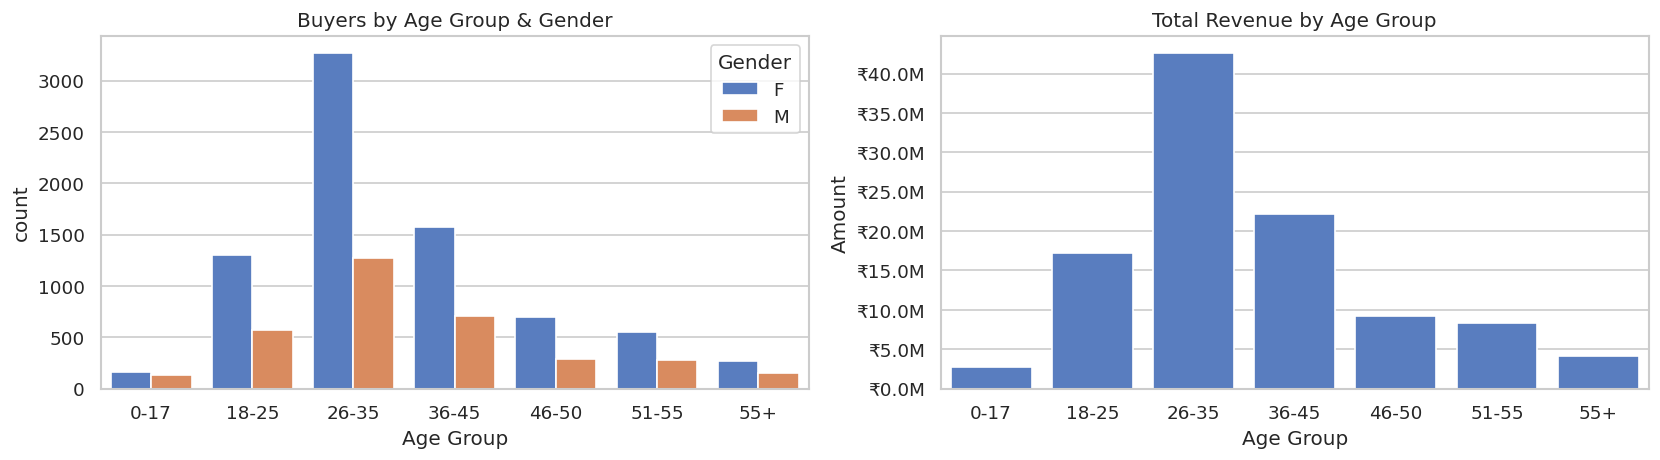

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Count by age + gender
sns.countplot(data=df, x='Age Group', hue='Gender',
              order=['0-17','18-25','26-35','36-45','46-50','51-55','55+'], ax=axes[0])
axes[0].set_title('Buyers by Age Group & Gender')
axes[0].legend(title='Gender')

# Revenue by age
sales_age = df.groupby('Age Group', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Age Group', y='Amount', data=sales_age,
            order=['0-17','18-25','26-35','36-45','46-50','51-55','55+'], ax=axes[1])
axes[1].set_title('Total Revenue by Age Group')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [12]:
# Average order value by age group
avg_order = df.groupby('Age Group')['Amount'].mean().sort_values(ascending=False).round(0)
print('Average Order Value by Age Group:')
for age, val in avg_order.items():
    print(f'  {age}: ₹{val:,.0f}')

Average Order Value by Age Group:
  51-55: ₹9,954
  36-45: ₹9,700
  55+: ₹9,557
  26-35: ₹9,384
  46-50: ₹9,367
  18-25: ₹9,175
  0-17: ₹9,120


> **Insight:** The **26–35 age group** drives the highest total revenue, but the **51–55 group has the highest average order value (₹9,954)** — they buy less frequently but spend more per transaction. Marketing campaigns should target 26–35 for volume and 51–55 for high-value product promotions.

### 3.3 State Analysis

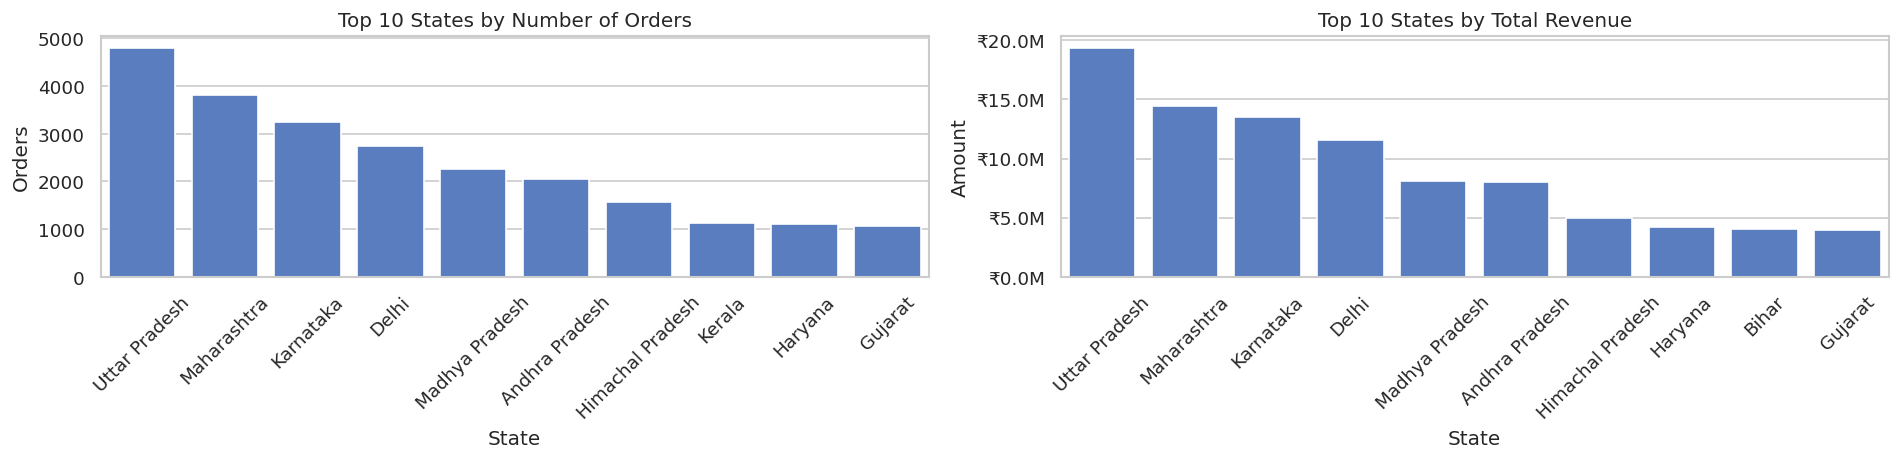

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Top 10 states by orders
sales_state_orders = df.groupby('State', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.barplot(data=sales_state_orders, x='State', y='Orders', ax=axes[0])
axes[0].set_title('Top 10 States by Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 states by revenue
sales_state_rev = df.groupby('State', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sns.barplot(data=sales_state_rev, x='State', y='Amount', ax=axes[1])
axes[1].set_title('Top 10 States by Total Revenue')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# % revenue from top 3 states
top3_states = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(3)
top3_pct = top3_states.sum() / total_revenue * 100
print('Top 3 states by revenue:')
for state, amt in top3_states.items():
    print(f'  {state}: ₹{amt:,.0f}  ({amt/total_revenue*100:.1f}% of total)')
print(f'\nTop 3 states combined: {top3_pct:.1f}% of total revenue')

Top 3 states by revenue:
  Uttar Pradesh: ₹19,374,968  (18.2% of total)
  Maharashtra: ₹14,427,543  (13.6% of total)
  Karnataka: ₹13,523,540  (12.7% of total)

Top 3 states combined: 44.5% of total revenue


> **Insight:** **Uttar Pradesh, Maharashtra, and Karnataka together contribute 44.5% of total revenue** — nearly half of all sales from just 3 of 16 states. These are priority markets for inventory stocking and targeted campaigns.

### 3.4 Marital Status Analysis

/tmp/ipykernel_593/1262450037.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Unmarried', 'Married'])
/tmp/ipykernel_593/1262450037.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Unmarried', 'Married'])


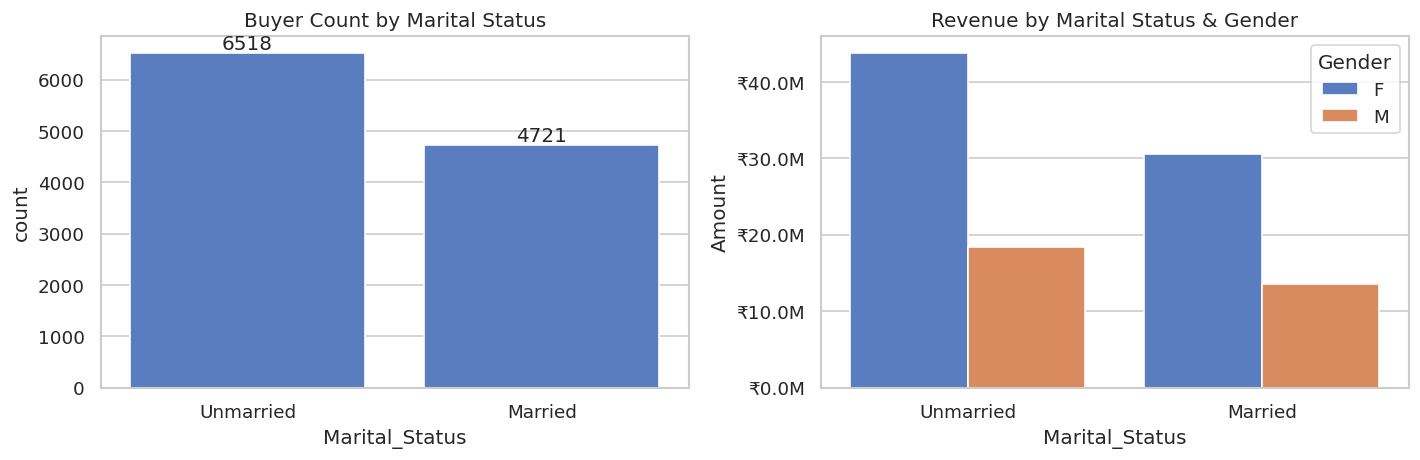

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Marital_Status', ax=axes[0])
axes[0].set_title('Buyer Count by Marital Status')
axes[0].set_xticklabels(['Unmarried', 'Married'])
for bars in axes[0].containers:
    axes[0].bar_label(bars)

sales_marital = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(data=sales_marital, x='Marital_Status', y='Amount', hue='Gender', ax=axes[1])
axes[1].set_title('Revenue by Marital Status & Gender')
axes[1].set_xticklabels(['Unmarried', 'Married'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [16]:
mw_revenue = df[(df['Marital_Status'] == 1) & (df['Gender'] == 'F')]['Amount'].sum()
print(f'Married women revenue: ₹{mw_revenue:,.0f}')
print(f'Married women % of total: {mw_revenue/total_revenue*100:.1f}%')

Married women revenue: ₹30,549,207
Married women % of total: 28.8%


> **Insight:** Married women are the single highest-spending segment — **contributing 28.8% of total revenue (₹3.06 Crore)** on their own. This demographic should be the primary focus for Diwali campaign targeting.

### 3.5 Occupation Analysis

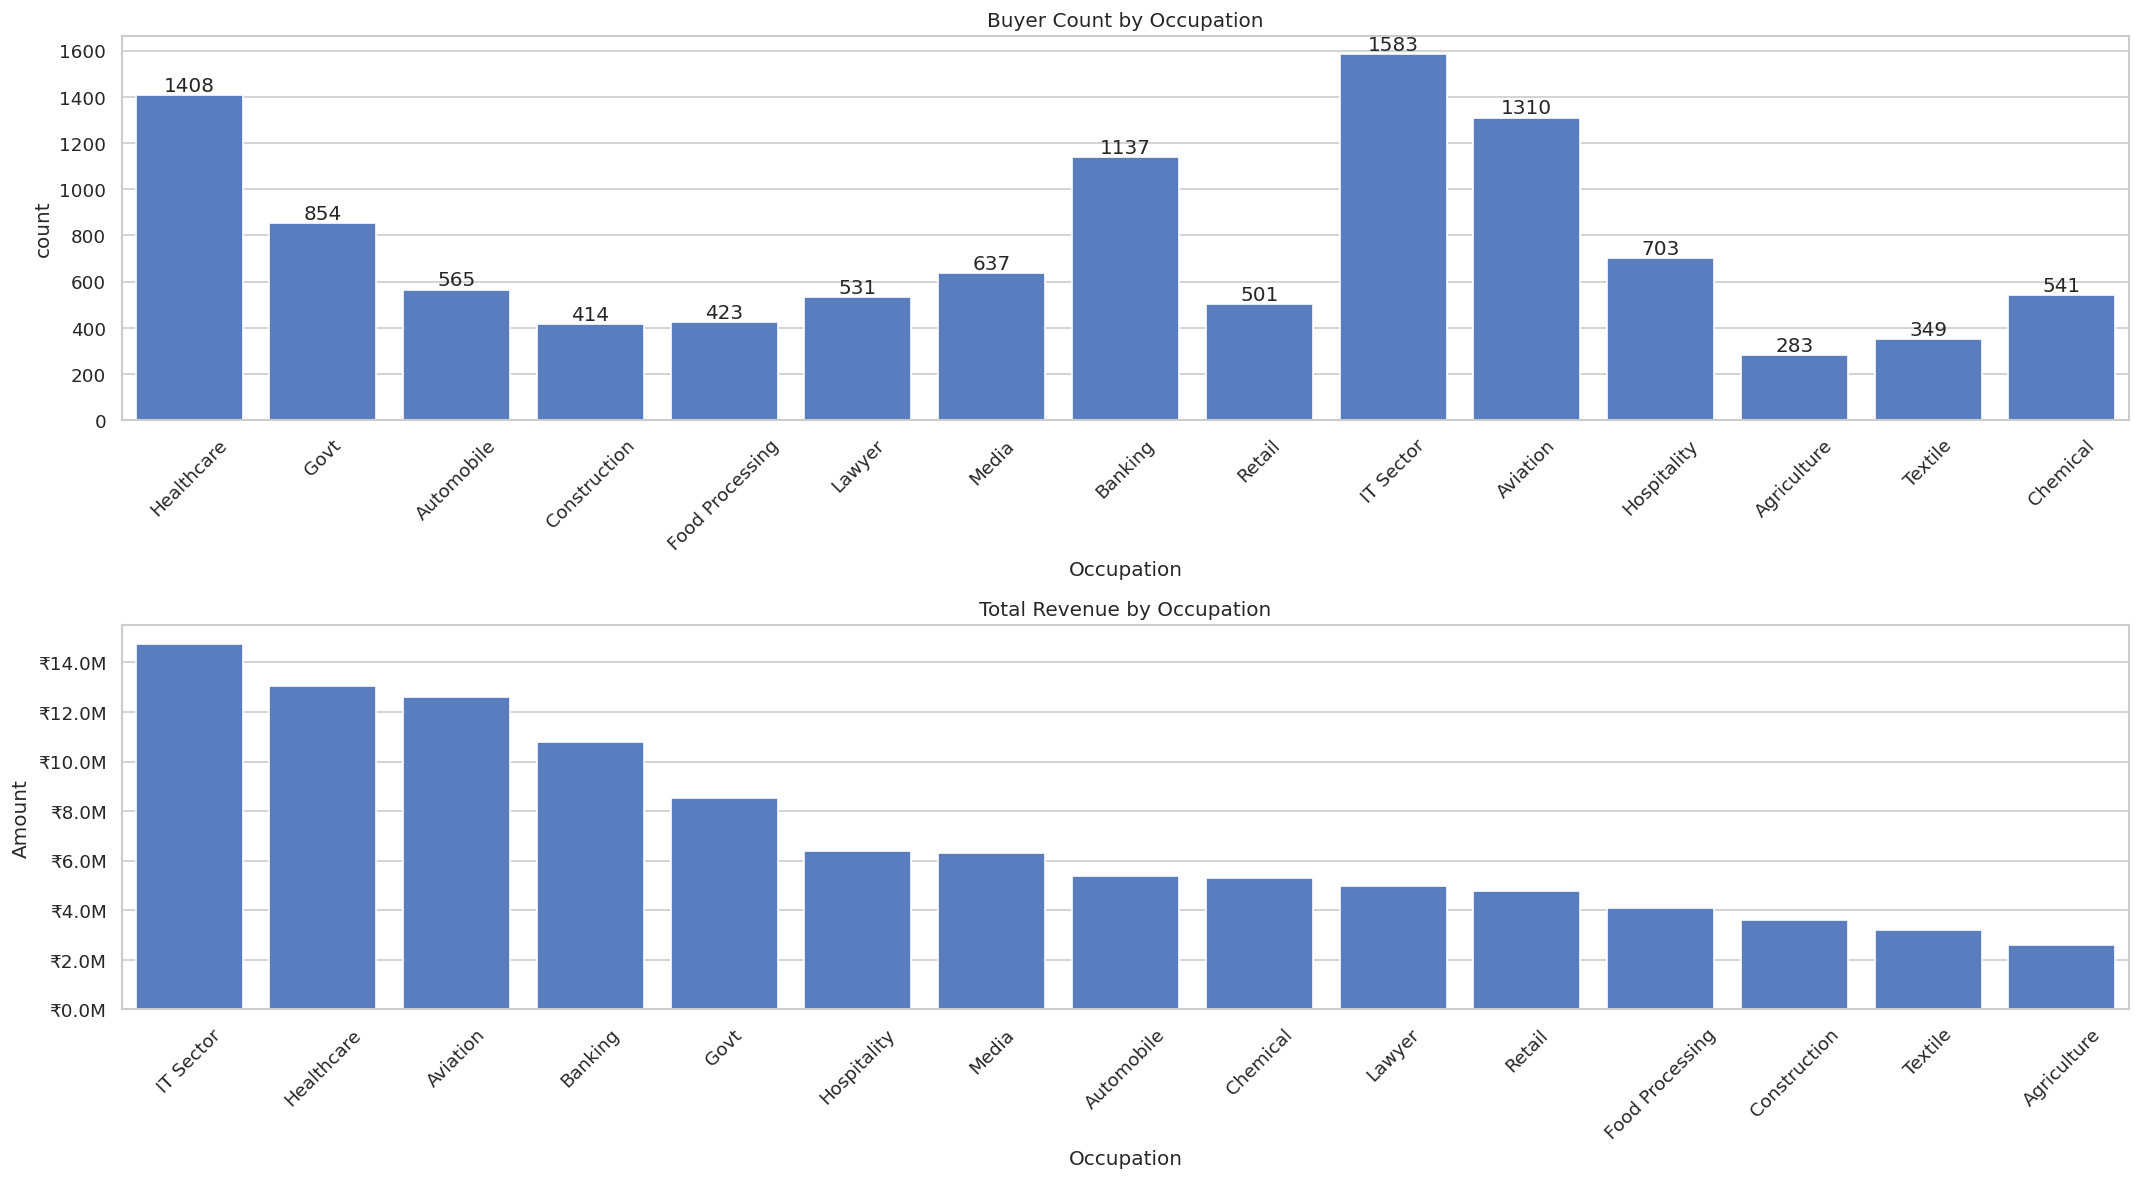

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

sns.countplot(data=df, x='Occupation', ax=axes[0])
axes[0].set_title('Buyer Count by Occupation')
axes[0].tick_params(axis='x', rotation=45)
for bars in axes[0].containers:
    axes[0].bar_label(bars)

sales_occ = df.groupby('Occupation', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(data=sales_occ, x='Occupation', y='Amount', ax=axes[1])
axes[1].set_title('Total Revenue by Occupation')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [18]:
top3_occ = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False).head(3)
print('Top 3 occupations by revenue:')
for occ, amt in top3_occ.items():
    print(f'  {occ}: ₹{amt:,.0f}  ({amt/total_revenue*100:.1f}% of total)')

Top 3 occupations by revenue:
  IT Sector: ₹14,755,079  (13.9% of total)
  Healthcare: ₹13,034,586  (12.3% of total)
  Aviation: ₹12,602,298  (11.9% of total)


> **Insight:** IT, Healthcare, and Aviation professionals are the top buyers by both count and revenue. These are typically high-income, digitally active segments — which explains both their purchasing power and likely online channel preference.

### 3.6 Product Category Analysis

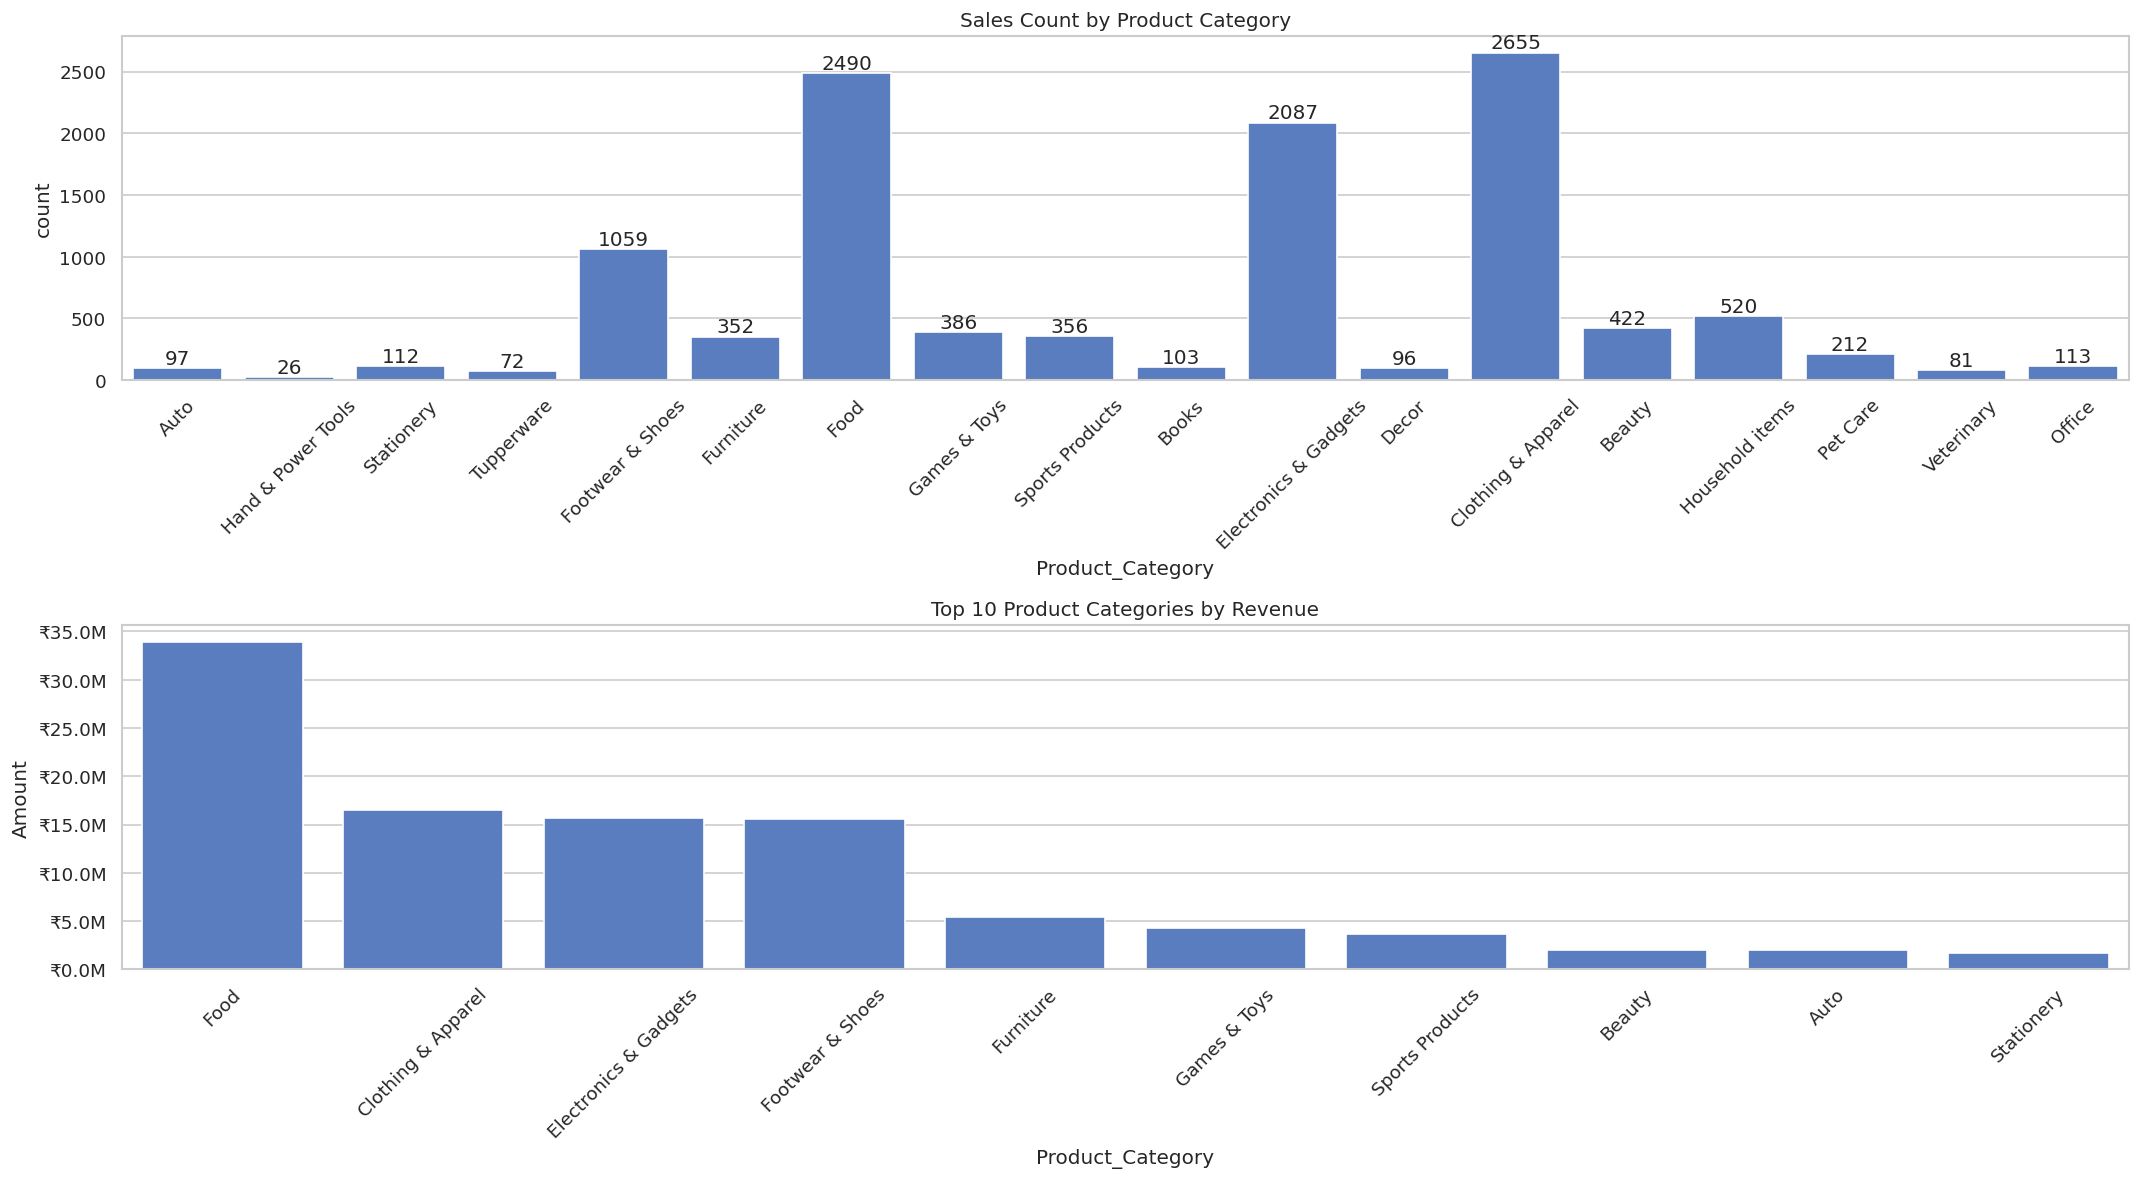

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

sns.countplot(data=df, x='Product_Category', ax=axes[0])
axes[0].set_title('Sales Count by Product Category')
axes[0].tick_params(axis='x', rotation=45)
for bars in axes[0].containers:
    axes[0].bar_label(bars)

sales_cat = df.groupby('Product_Category', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sns.barplot(data=sales_cat, x='Product_Category', y='Amount', ax=axes[1])
axes[1].set_title('Top 10 Product Categories by Revenue')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [20]:
top3_cat = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).head(3)
print('Top 3 product categories by revenue:')
for cat, amt in top3_cat.items():
    print(f'  {cat}: ₹{amt:,.0f}  ({amt/total_revenue*100:.1f}% of total)')
print(f'\nTop 3 categories combined: {top3_cat.sum()/total_revenue*100:.1f}% of total revenue')

Top 3 product categories by revenue:
  Food: ₹33,933,883  (31.9% of total)
  Clothing & Apparel: ₹16,495,019  (15.5% of total)
  Electronics & Gadgets: ₹15,643,846  (14.7% of total)

Top 3 categories combined: 62.2% of total revenue


> **Insight:** Food, Clothing & Apparel, and Electronics & Gadgets account for **62.2% of total revenue**. Any stock shortage in these 3 categories during the Diwali season would have an outsized impact on overall sales performance.

### 3.7 Top Products by Orders

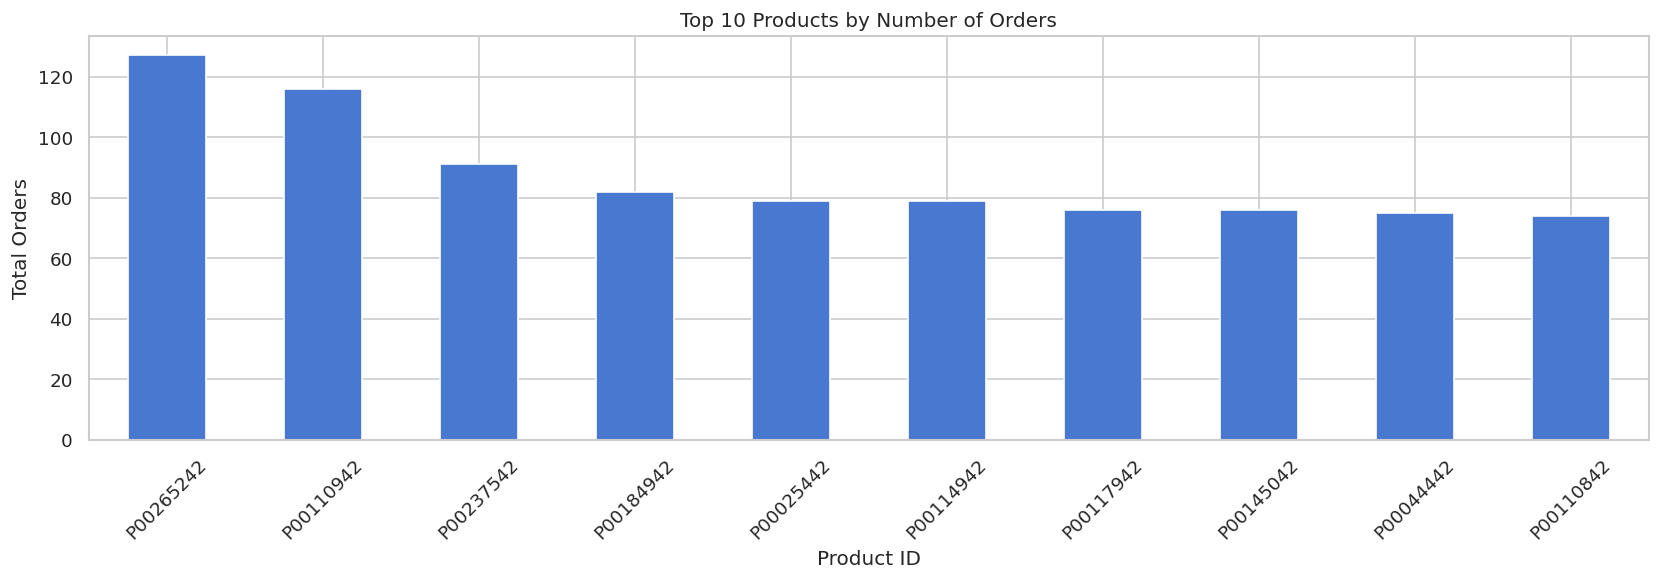

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar', ax=ax, color=sns.color_palette('muted')[0])
ax.set_title('Top 10 Products by Number of Orders')
ax.set_xlabel('Product ID')
ax.set_ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

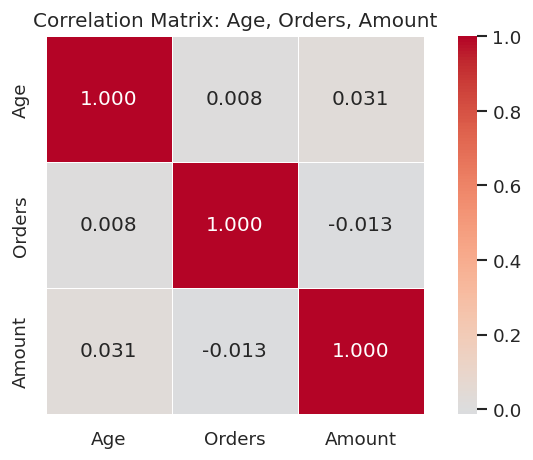


Correlation coefficients:
          Age  Orders  Amount
Age     1.000   0.008   0.031
Orders  0.008   1.000  -0.013
Amount  0.031  -0.013   1.000


In [22]:
corr = df[['Age', 'Orders', 'Amount']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Age, Orders, Amount')
plt.tight_layout()
plt.show()

print('\nCorrelation coefficients:')
print(corr.round(3))

> **Insight:** Age, Orders, and Amount show near-zero correlation with each other (all coefficients < 0.05). This means **spending amount is not determined by age or number of previous orders alone** — segment identity (gender, occupation, marital status) is a stronger predictor than these numeric variables.

## 5. Conclusion & Business Recommendations

### Key Customer Profile
The highest-value Diwali buyers are:
> **Married women, aged 26–35, from Uttar Pradesh / Maharashtra / Karnataka, working in IT, Healthcare, or Aviation**

### Quantified Findings

| Dimension | Finding |
|-----------|---------|
| Gender | Female buyers = **70% of total revenue (₹7.4 Crore)** |
| Age group | 26–35 = highest revenue; 51–55 = highest avg order value (₹9,954) |
| Geography | Top 3 states (UP, MH, KA) = **44.5% of total revenue** |
| Marital status | Married women alone = **28.8% of total revenue (₹3.06 Crore)** |
| Occupation | IT, Healthcare, Aviation = top 3 sectors |
| Product mix | Food + Clothing + Electronics = **62.2% of total revenue** |

### Business Recommendations
1. **Concentrate ad spend** on married women aged 26–35 in UP, Maharashtra, and Karnataka for maximum ROI on Diwali campaigns.
2. **Stock up on Food, Clothing & Apparel, and Electronics** before peak season — a stockout in these 3 categories risks losing 62% of potential revenue.
3. **Design high-value product bundles** for the 51–55 segment — they have the highest spend per order despite lower volume.
4. **Use digital channels** preferentially — IT and Healthcare professionals are likely the most digitally active buyers.
